<a href="https://colab.research.google.com/github/Muen1/multilingual-health-qa-africa/blob/main/notebooks/03_finetuning_exp6.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# CELL 0 — Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')
import os

BASE_DIR = '/content/drive/MyDrive/multilingual_health_qa'
DATA_DIR = f'{BASE_DIR}/data'
OUT_DIR  = f'{BASE_DIR}/outputs'
PLOT_DIR = f'{BASE_DIR}/plots'
SUB_DIR  = f'{BASE_DIR}/submissions'

for d in [OUT_DIR, PLOT_DIR]:
    os.makedirs(d, exist_ok=True)

print("Drive mounted.")
print("Data files:", os.listdir(DATA_DIR))

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Drive mounted.
Data files: ['Train.csv', 'Val.csv', 'Test.csv', 'SampleSubmission.csv', 'train_clean.csv', 'val_clean.csv', 'test_clean.csv', 'predictions_exp01_mt5small_zeroshot.csv', 'predictions_exp02_mt5small_lora_r16.csv', 'predictions_exp04_flanT5base_lora_r32.csv', 'predictions_exp05_flanT5base_promptv2.csv', 'predictions_exp03_flanT5base_lora_r16.csv', 'experiment_log.json']


In [2]:
import os
checkpoint_dir = "/content/drive/MyDrive/multilingual_health_qa/outputs/checkpoints_exp06_flanT5large_lora_r16"
if os.path.exists(checkpoint_dir):
    print(" Checkpoints found:", os.listdir(checkpoint_dir))
else:
    print(" No checkpoints — will start from scratch")

 Checkpoints found: ['checkpoint-1864', 'checkpoint-3728']


In [3]:
# CELL S2 — Install only what's missing (compatible with Colab's pre-installed versions)
!pip install -q evaluate rouge-score sentencepiece

# Verify
import importlib
packages = ['transformers', 'datasets', 'peft', 'accelerate', 'evaluate', 'rouge_score', 'sentencepiece']
print("\n=== Installed versions ===")
for p in packages:
    try:
        mod = importlib.import_module(p)
        ver = getattr(mod, '__version__', 'installed')
        print(f"  ✓ {p}: {ver}")
    except:
        print(f"  ✗ {p}: MISSING")

print("\nInstallation complete — no restart needed.")


=== Installed versions ===
  ✓ transformers: 5.10.2
  ✓ datasets: 4.0.0


  ✓ peft: 0.19.1
  ✓ accelerate: 1.13.0
  ✓ evaluate: 0.4.6
  ✓ rouge_score: installed
  ✓ sentencepiece: 0.2.1

Installation complete — no restart needed.


In [4]:
# CELL S3 — Package check
import importlib, sys

required = {
    'transformers': '4.0',
    'datasets': '2.0',
    'peft': '0.5',
    'accelerate': '0.20',
    'evaluate': '0.4',
    'rouge_score': '0.1',
    'sentencepiece': '0.1',
}

print("=== Package check ===")
all_ok = True
for pkg, min_ver in required.items():
    try:
        mod = importlib.import_module(pkg)
        ver = getattr(mod, '__version__', '?')
        print(f"  ✓ {pkg}: {ver}")
    except ImportError:
        print(f"  ✗ {pkg}: MISSING")
        all_ok = False

if all_ok:
    print("\n✓ All packages present — ready to continue.")
else:
    print("\n✗ Run: !pip install -q evaluate rouge-score sentencepiece")

=== Package check ===
  ✓ transformers: 5.10.2
  ✓ datasets: 4.0.0
  ✓ peft: 0.19.1
  ✓ accelerate: 1.13.0
  ✓ evaluate: 0.4.6
  ✓ rouge_score: ?
  ✓ sentencepiece: 0.2.1

✓ All packages present — ready to continue.


In [5]:
# imports
import gc
import os
import json
import pandas as pd
import numpy as np
import torch
import matplotlib.pyplot as plt
import evaluate as hf_evaluate
from tqdm import tqdm
from transformers import (
    AutoTokenizer,
    AutoModelForSeq2SeqLM,
    Seq2SeqTrainer,
    Seq2SeqTrainingArguments,
    DataCollatorForSeq2Seq,
    EarlyStoppingCallback
)
from peft import get_peft_model, LoraConfig, TaskType
from datasets import Dataset

print("PyTorch version :", torch.__version__)
print("CUDA available  :", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU             :", torch.cuda.get_device_name(0))
else:
    print("WARNING: No GPU detected. Go to Runtime → Change runtime type → T4 GPU")

PyTorch version : 2.11.0+cu128
CUDA available  : True
GPU             : Tesla T4


In [6]:
# CELL S4 — Load cleaned data
train = pd.read_csv(f'{DATA_DIR}/train_clean.csv')
val   = pd.read_csv(f'{DATA_DIR}/val_clean.csv')
test  = pd.read_csv(f'{DATA_DIR}/test_clean.csv')

# Column mapping for this dataset
q_col    = 'input'
a_col    = 'output'
lang_col = 'subset'
id_col   = 'ID'

# Rebuild prompts v1 if missing
if 'input_text' not in train.columns:
    def _prompt_v1(q, l):
        return f"Language: {l}\nQuestion: {q}\nAnswer:"
    train['input_text']  = train.apply(lambda r: _prompt_v1(r[q_col], r[lang_col]), axis=1)
    train['target_text'] = train[a_col].astype(str)
    val['input_text']    = val.apply(lambda r: _prompt_v1(r[q_col], r[lang_col]), axis=1)
    val['target_text']   = val[a_col].astype(str)
    test['input_text']   = test.apply(lambda r: _prompt_v1(r[q_col], r[lang_col]), axis=1)

print(f"Train: {len(train)}, Val: {len(val)}, Test: {len(test)}")
print("Sample input:", train['input_text'].iloc[0])
print("Sample target:", train['target_text'].iloc[0][:150])

Train: 29814, Val: 6686, Test: 2618
Sample input: Language: Aka_Gha
Question: Ɔkwan bɛn so na mmabunbɛtumi aboa wɔn mfɛfoɔ a nsa anaa nnubɔne ama wɔayɛ wɔn ayayadeɛ? Yei bi ne sɛnea wɔbɛkyekye wɔn werɛ, sɛnea wɔbɛboa wɔn ma wɔanya mmoa firi nnwumakuo a ɛfata hɔ, ne sɛnea wɔbɛsiw afɔbu suban ne nsɛm a nkurɔfoɔ de gu oyarefoɔ no so no kwan.
Answer:
Sample target: Mmabun betumi aboa atipɛnfo a ebia nsa anaa nnubɔne ama wɔayɛ wɔn ayayadeɛ so denam: Nkate fam mmoa a wɔde bɛma na wɔagye wɔn nkate atom a wɔremmu atɛ


In [7]:
# CELL S5 — Load sample submission and verify format
sample = pd.read_csv(f'{DATA_DIR}/SampleSubmission.csv')
print(" Sample submission loaded")
print(f"  Columns : {sample.columns.tolist()}")
print(f"  Shape   : {sample.shape}")
print(f"\nFirst 2 rows:")
print(sample.head(2).to_string())

 Sample submission loaded
  Columns : ['ID', 'TargetRLF1', 'TargetR1F1', 'TargetLLM']
  Shape   : (2618, 4)

First 2 rows:
                       ID             TargetRLF1             TargetR1F1              TargetLLM
0  ID_TS_Aka_Gha_A3B1799D  Wuna dey craze, eweeh  Wuna dey craze, eweeh  Wuna dey craze, eweeh
1  ID_TS_Aka_Gha_1C80317F  Wuna dey craze, eweeh  Wuna dey craze, eweeh  Wuna dey craze, eweeh


In [ ]:
# FIX — Upgrade torchao to fix peft compatibility
# RUN ONCE AND NEVER AGAIN
!pip install -q --upgrade torchao

# Restart runtime after this installs
import os
os.kill(os.getpid(), 9)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 64.3 MB/s eta 0:00:00


In [8]:
# Confirm torchao version is correct
import torchao
import peft
import torch

print(f"torchao : {torchao.__version__}")
print(f"peft    : {peft.__version__}")
print(f"torch   : {torch.__version__}")
print(f"GPU     : {torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'NOT AVAILABLE'}")

# Quick test that get_peft_model works without the ImportError
from peft import LoraConfig, TaskType, get_peft_model
from transformers import AutoModelForSeq2SeqLM

print("\nTesting peft import...")
test_model = AutoModelForSeq2SeqLM.from_pretrained("google/flan-t5-base")
test_lora  = LoraConfig(task_type=TaskType.SEQ_2_SEQ_LM, r=8, lora_alpha=16,
                         target_modules=["q", "v"], bias="none")
test_model = get_peft_model(test_model, test_lora)
print("✓ get_peft_model works correctly")
print("✓ Ready to run experiments")

del test_model

torchao : 0.17.0
peft    : 0.19.1
torch   : 2.11.0+cu128
GPU     : Tesla T4

Testing peft import...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/1.40k [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/990M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/282 [00:00<?, ?it/s]

[transformers] The tied weights mapping and config for this model specifies to tie shared.weight to lm_head.weight, but both are present in the checkpoints with different values, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning.


generation_config.json:   0%|          | 0.00/147 [00:00<?, ?B/s]

✓ get_peft_model works correctly
✓ Ready to run experiments


In [9]:
# CELL S6 — All shared helper functions

#  1. ROUGE metric
rouge_metric = hf_evaluate.load("rouge")

#  2. Tokenize datasets
def get_tokenized_datasets(tokenizer, train_df, val_df,
                            max_input=128, max_target=64):
    def preprocess(examples):
        inputs = tokenizer(
            examples['input_text'],
            max_length=max_input,
            truncation=True,
            padding='max_length'
        )
        targets = tokenizer(
            examples['target_text'],
            max_length=max_target,
            truncation=True,
            padding='max_length'
        )
        labels = [
            [(l if l != tokenizer.pad_token_id else -100) for l in label]
            for label in targets['input_ids']
        ]
        inputs['labels'] = labels
        return inputs

    train_ds  = Dataset.from_pandas(
        train_df[['input_text','target_text']].reset_index(drop=True))
    val_ds    = Dataset.from_pandas(
        val_df[['input_text','target_text']].reset_index(drop=True))
    train_tok = train_ds.map(preprocess, batched=True,
                             remove_columns=['input_text','target_text'])
    val_tok   = val_ds.map(preprocess,   batched=True,
                           remove_columns=['input_text','target_text'])
    return train_tok, val_tok

# 3. Compute metrics
def make_compute_metrics(tokenizer):
    def compute_metrics(eval_preds):
        preds, labels = eval_preds
        if isinstance(preds, tuple):
            preds = preds[0]

        preds  = np.where(preds  != -100, preds,  tokenizer.pad_token_id)
        labels = np.where(labels != -100, labels, tokenizer.pad_token_id)
        preds  = np.clip(preds, 0, tokenizer.vocab_size - 1)

        decoded_preds  = tokenizer.batch_decode(
            preds,  skip_special_tokens=True)
        decoded_labels = tokenizer.batch_decode(
            labels, skip_special_tokens=True)
        decoded_preds  = [p.strip() for p in decoded_preds]
        decoded_labels = [l.strip() for l in decoded_labels]
        result = rouge_metric.compute(
            predictions=decoded_preds,
            references=decoded_labels,
            use_stemmer=True
        )
        return {
            "rouge1": round(result["rouge1"], 4),
            "rougeL": round(result["rougeL"], 4)
        }
    return compute_metrics

# 4. Training
def run_training(model, tokenizer, train_tok, val_tok,
                 experiment_name, learning_rate,
                 num_epochs, batch_size, max_target_len):
    args = Seq2SeqTrainingArguments(
        output_dir=f"{OUT_DIR}/checkpoints_{experiment_name}",
        num_train_epochs=num_epochs,
        per_device_train_batch_size=4,
        per_device_eval_batch_size=4,
        gradient_accumulation_steps=4,
        warmup_steps=50,
        learning_rate=learning_rate,
        weight_decay=0.01,
        fp16=True,
        eval_strategy="epoch",
        save_strategy="epoch",
        load_best_model_at_end=True,
        metric_for_best_model="eval_loss",
        predict_with_generate=True,
        generation_max_length=64,
        logging_steps=50,
        report_to="none",
        push_to_hub=False
    )
    collator = DataCollatorForSeq2Seq(tokenizer, model=model, padding=True)
    trainer  = Seq2SeqTrainer(
        model=model,
        args=args,
        train_dataset=train_tok,
        eval_dataset=val_tok,
        processing_class=tokenizer,
        data_collator=collator,
        compute_metrics=make_compute_metrics(tokenizer),
        callbacks=[EarlyStoppingCallback(early_stopping_patience=2)]
    )
    est = len(train_tok) * num_epochs / (4 * 4) / 60
    print(f" Estimated time : ~{est:.0f} minutes")
    print("Starting training...")
    trainer.train(resume_from_checkpoint=True)
    return trainer

# 5. Save model
def save_model(model, tokenizer, experiment_name):
    path = f'{OUT_DIR}/model_{experiment_name}'
    os.makedirs(path, exist_ok=True)
    model.save_pretrained(path)
    tokenizer.save_pretrained(path)
    print(f" Model saved : {path}")
    return path

# 6. Generate answers
def generate_answers(model, tokenizer, texts,
                     max_input=128, max_target=64,
                     batch_size=8, num_beams=4):
    model.eval()
    if torch.cuda.is_available():
        model = model.cuda()
    all_answers = []
    for i in tqdm(range(0, len(texts), batch_size), desc="Generating"):
        batch  = texts[i:i+batch_size]
        inputs = tokenizer(
            batch, return_tensors='pt',
            max_length=max_input,
            truncation=True, padding=True
        )
        if torch.cuda.is_available():
            inputs = {k: v.cuda() for k, v in inputs.items()}
        with torch.no_grad():
            outputs = model.generate(
                **inputs,
                max_new_tokens=max_target,
                num_beams=num_beams,
                no_repeat_ngram_size=3,
                length_penalty=1.0
            )
        decoded = tokenizer.batch_decode(outputs, skip_special_tokens=True)
        all_answers.extend(decoded)
    return all_answers

# 7. Save predictions
def save_predictions(test_df, answers, experiment_name):
    out              = test_df.copy()
    out['predicted_answer'] = answers
    path             = f'{DATA_DIR}/predictions_{experiment_name}.csv'
    out.to_csv(path, index=False)
    print(f" Predictions saved : {path}")
    return path

# 8. Build Zindi submission
def build_submission(experiment_name):
    pred_path = f'{DATA_DIR}/predictions_{experiment_name}.csv'
    if not os.path.exists(pred_path):
        print(f"✗ No predictions found for {experiment_name}")
        print(f"  Expected at: {pred_path}")
        return None

    preds       = pd.read_csv(pred_path)
    pred_id_col = preds.columns[0]
    pred_answer = preds['predicted_answer'].astype(str).values

    submission  = pd.DataFrame({
        'ID':         preds[pred_id_col].values,
        'TargetRLF1': pred_answer,
        'TargetR1F1': pred_answer,
        'TargetLLM':  pred_answer
    })

    assert list(submission.columns) == ['ID','TargetRLF1','TargetR1F1','TargetLLM'], \
        "Column mismatch!"
    assert len(submission) == len(sample), \
        f"Row mismatch: {len(submission)} vs {len(sample)}"
    assert submission.isnull().sum().sum() == 0, \
        "Null values found!"

    path = f'{SUB_DIR}/submission_{experiment_name}.csv'
    submission.to_csv(path, index=False)
    print(f" Submission saved  : {path}")
    print(f"  Shape             : {submission.shape}")
    print(f"  Columns           : {submission.columns.tolist()}")
    print(f"\nFirst 3 rows:")
    print(submission.head(3).to_string())
    return path

# 9. Plot learning curves
def plot_learning_curves(trainer, experiment_name):
    log      = trainer.state.log_history
    t_steps  = [x['step']      for x in log
                if 'loss' in x and 'eval_loss' not in x]
    t_losses = [x['loss']      for x in log
                if 'loss' in x and 'eval_loss' not in x]
    e_epochs = [x['epoch']     for x in log if 'eval_loss' in x]
    e_losses = [x['eval_loss'] for x in log if 'eval_loss' in x]
    e_r1     = [x.get('eval_rouge1', 0) for x in log if 'eval_loss' in x]
    e_rL     = [x.get('eval_rougeL', 0) for x in log if 'eval_loss' in x]

    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    fig.suptitle(f'Learning Curves — {experiment_name}',
                 fontsize=13, fontweight='bold')

    axes[0].plot(t_steps, t_losses, color='royalblue', linewidth=1.5)
    axes[0].set_title('Training Loss')
    axes[0].set_xlabel('Step')
    axes[0].set_ylabel('Loss')
    axes[0].grid(True, alpha=0.4)

    axes[1].plot(e_epochs, e_losses, color='darkorange',
                 marker='o', linewidth=2)
    axes[1].set_title('Validation Loss per Epoch')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Eval Loss')
    axes[1].grid(True, alpha=0.4)

    axes[2].plot(e_epochs, e_r1, color='green',
                 marker='o', linewidth=2, label='ROUGE-1')
    axes[2].plot(e_epochs, e_rL, color='purple',
                 marker='s', linewidth=2, label='ROUGE-L')
    axes[2].set_title('ROUGE Scores per Epoch')
    axes[2].set_xlabel('Epoch')
    axes[2].set_ylabel('F1 Score')
    axes[2].legend()
    axes[2].grid(True, alpha=0.4)

    plt.tight_layout()
    path = f'{PLOT_DIR}/learning_curves_{experiment_name}.png'
    plt.savefig(path, dpi=150, bbox_inches='tight')
    plt.show()
    print(f"✓ Learning curves saved : {path}")

#  10. Experiment log
LOG_PATH = f'{DATA_DIR}/experiment_log.json'

def save_experiment_log(experiment_name, config, metrics):
    log = {}
    if os.path.exists(LOG_PATH):
        with open(LOG_PATH, 'r') as f:
            log = json.load(f)
    log[experiment_name] = {"config": config, "metrics": metrics}
    with open(LOG_PATH, 'w') as f:
        json.dump(log, f, indent=2)
    print(f"✓ Experiment log updated : {LOG_PATH}")
    print(json.dumps(log[experiment_name], indent=2))

def update_zindi_score(experiment_name, score):
    if not os.path.exists(LOG_PATH):
        print("No log file found. Run the experiment first.")
        return
    with open(LOG_PATH, 'r') as f:
        log = json.load(f)
    if experiment_name not in log:
        print(f"Experiment {experiment_name} not in log.")
        return
    log[experiment_name]['metrics']['zindi_score'] = score
    with open(LOG_PATH, 'w') as f:
        json.dump(log, f, indent=2)
    print(f"✓ Zindi score updated: {experiment_name} = {score}")

# 11. Check if already done
def is_done(experiment_name):
    pred_path = f'{DATA_DIR}/predictions_{experiment_name}.csv'
    if os.path.exists(pred_path):
        print(f"✓ ALREADY DONE: {experiment_name}")
        print(f"  Predictions at: {pred_path}")
        print("  Skipping to submission cell.")
        return True
    print(f" NOT YET DONE: {experiment_name} — will run now.")
    return False

# 12. Free GPU memory
def free_gpu(*objects):
    for obj in objects:
        del obj
    gc.collect()
    torch.cuda.empty_cache()
    if torch.cuda.is_available():
        used = torch.cuda.memory_allocated() / 1e9
        free = torch.cuda.mem_get_info()[0] / 1e9
        print(f" GPU memory freed")
        print(f"  Used : {used:.2f} GB")
        print(f"  Free : {free:.2f} GB")

print("✓ All helper functions loaded and ready.")

✓ All helper functions loaded and ready.


In [10]:
# CELL S7 — Check what experiments are already done
import os, json

print("=== EXPERIMENT STATUS ===\n")

experiments_list = [
    "exp01_mt5small_zeroshot",
    "exp02_mt5small_lora_r16",
    "exp03_flanT5base_lora_r16",
    "exp04_flanT5base_lora_r32",
    "exp05_flanT5base_promptv2",
    "exp06_flanT5large_lora_r16"
]

for exp in experiments_list:
    pred_path = f'{DATA_DIR}/predictions_{exp}.csv'
    sub_path  = f'{DATA_DIR}/../submissions/submission_{exp}.csv'
    done      = "✓ DONE" if os.path.exists(pred_path) else "✗ NOT DONE"
    submitted = "✓ SUBMITTED" if os.path.exists(sub_path) else "✗ NOT SUBMITTED"
    print(f"{exp}")
    print(f"  Predictions : {done}")
    print(f"  Submission  : {submitted}")
    print()

if os.path.exists(LOG_PATH):
    print("=== SCORES SO FAR ===")
    with open(LOG_PATH, 'r') as f:
        log = json.load(f)
    for name, entry in log.items():
        m = entry.get('metrics', {})
        print(f"  {name}")
        print(f"    ROUGE-1    : {m.get('val_rouge1', 'N/A')}")
        print(f"    ROUGE-L    : {m.get('val_rougeL', 'N/A')}")
        print(f"    Zindi Score: {m.get('zindi_score', 'not yet')}")
        print()
else:
    print("No experiment log yet — starting fresh.")

=== EXPERIMENT STATUS ===

exp01_mt5small_zeroshot
  Predictions : ✓ DONE
  Submission  : ✓ SUBMITTED

exp02_mt5small_lora_r16
  Predictions : ✓ DONE
  Submission  : ✓ SUBMITTED

exp03_flanT5base_lora_r16
  Predictions : ✓ DONE
  Submission  : ✓ SUBMITTED

exp04_flanT5base_lora_r32
  Predictions : ✓ DONE
  Submission  : ✓ SUBMITTED

exp05_flanT5base_promptv2
  Predictions : ✓ DONE
  Submission  : ✓ SUBMITTED

exp06_flanT5large_lora_r16
  Predictions : ✗ NOT DONE
  Submission  : ✗ NOT SUBMITTED

=== SCORES SO FAR ===
  exp02_mt5small_lora_r16
    ROUGE-1    : 0.0034
    ROUGE-L    : 0.0033
    Zindi Score: 0.004928

  exp04_flanT5base_lora_r32
    ROUGE-1    : 0.1057
    ROUGE-L    : 0.091
    Zindi Score: pending

  exp05_flanT5base_promptv2
    ROUGE-1    : 0.0773
    ROUGE-L    : 0.069
    Zindi Score: pending

  exp03_flanT5base_lora_r16
    ROUGE-1    : 0.1056
    ROUGE-L    : 0.091
    Zindi Score: 0.155076



Free GPU memory: 15.5 GB
 NOT YET DONE: exp06_flanT5large_lora_r16 — will run now.

EXPERIMENT 6 : exp06_flanT5large_lora_r16
Model        : google/flan-t5-large
LoRA         : r=16, alpha=32
Batch        : 4 per device × 4 accum = 16 effective
NOTE         : Takes ~60–90 min on T4 GPU



config.json:   0%|          | 0.00/662 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/2.54k [00:00<?, ?B/s]

spiece.model:   0%|          | 0.00/792k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/2.42M [00:00<?, ?B/s]

...

Map:   0%|          | 0/29814 [00:00<?, ? examples/s]

Map:   0%|          | 0/6686 [00:00<?, ? examples/s]

 Estimated time : ~93 minutes
Starting training...


Epoch,Training Loss,Validation Loss,Rouge1,Rougel
3,0.000000,2.605851,0.077700,0.069600


 Model saved : /content/drive/MyDrive/multilingual_health_qa/outputs/model_exp06_flanT5large_lora_r16


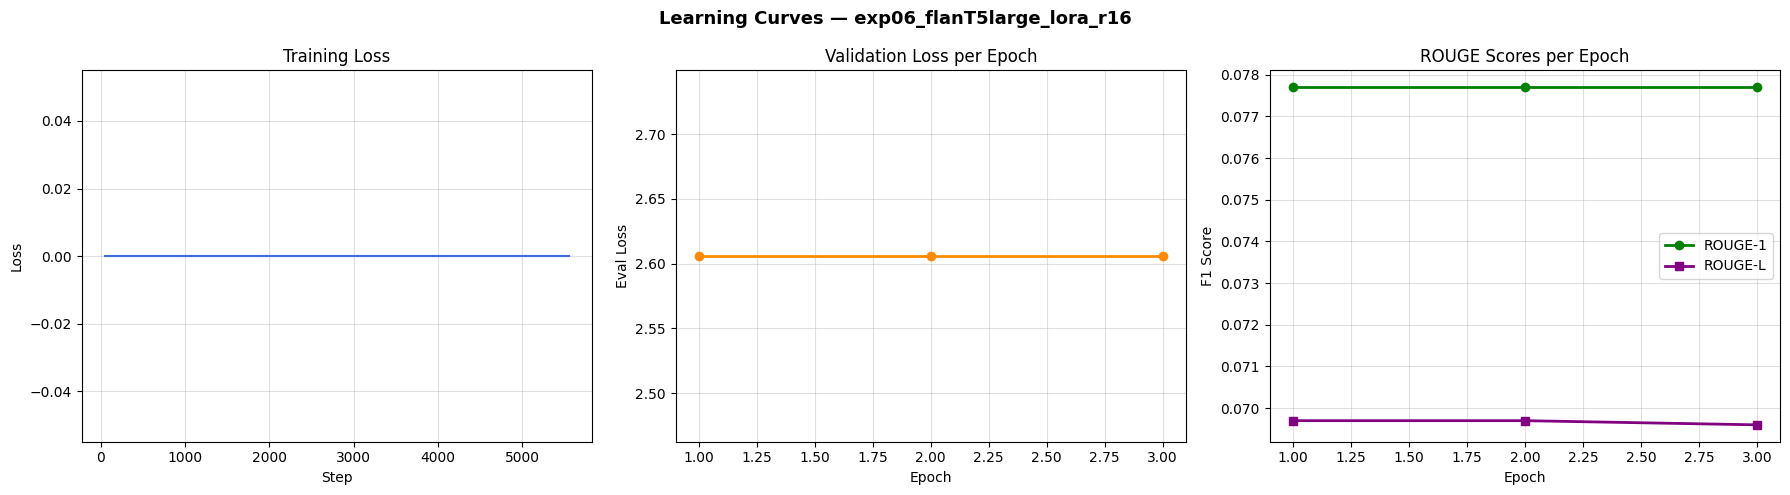

✓ Learning curves saved : /content/drive/MyDrive/multilingual_health_qa/plots/learning_curves_exp06_flanT5large_lora_r16.png

✓ Val ROUGE-1 : 0.0777
✓ Val ROUGE-L : 0.0696

Running inference on test set...


Generating: 100%|██████████| 655/655 [31:06<00:00,  2.85s/it]


 Predictions saved : /content/drive/MyDrive/multilingual_health_qa/data/predictions_exp06_flanT5large_lora_r16.csv
✓ Experiment log updated : /content/drive/MyDrive/multilingual_health_qa/data/experiment_log.json
{
  "config": {
    "model": "google/flan-t5-large",
    "lora": true,
    "lora_r": 16,
    "lora_alpha": 32,
    "learning_rate": 0.0003,
    "epochs": 3,
    "batch_size": 4,
    "max_input": 128,
    "max_target": 64,
    "prompt_version": "v1",
    "note": "float16 loading + reduced sequence lengths to fit T4",
    "purpose": "Model scale effect \u2014 large vs base"
  },
  "metrics": {
    "val_rouge1": 0.0777,
    "val_rougeL": 0.0696,
    "zindi_score": "pending"
  }
}
 GPU memory freed
  Used : 1.98 GB
  Free : 13.43 GB

EXPERIMENT 6 COMPLETE


In [11]:
# EXPERIMENT 6 — flan-t5-large with LoRA r=16
# WHAT    : Scale backbone to flan-t5-large (3× bigger than base)
# WHY     : Larger models have more language understanding.
#           Tests whether model scale alone improves multilingual
#           health QA beyond what prompt/LoRA tuning achieved.
#           Uses float16 + smaller batch to fit T4 GPU memory.
# CHANGE  : flan-t5-base → flan-t5-large, batch_size 4, float16
# NOTE    : Takes ~60–90 min on T4. Do NOT interrupt mid-training.

# Free GPU memory before starting
import gc, torch
gc.collect()
torch.cuda.empty_cache()
free_mem = torch.cuda.mem_get_info()[0] / 1e9
print(f"Free GPU memory: {free_mem:.1f} GB")

if free_mem < 4.0:
    raise RuntimeError(
        "Not enough GPU memory. Go to Runtime → Disconnect and delete runtime, "
        "then reconnect and re-run setup cells S0→S7 before Exp 6."
    )

EXP6 = "exp06_flanT5large_lora_r16"

if not is_done(EXP6):
    print(f"\n{'='*60}")
    print(f"EXPERIMENT 6 : {EXP6}")
    print(f"Model        : google/flan-t5-large")
    print(f"LoRA         : r=16, alpha=32")
    print(f"Batch        : 4 per device × 4 accum = 16 effective")
    print(f"NOTE         : Takes ~60–90 min on T4 GPU")
    print(f"{'='*60}\n")

    tok6   = AutoTokenizer.from_pretrained("google/flan-t5-large")
    model6 = AutoModelForSeq2SeqLM.from_pretrained(
        "google/flan-t5-large",
        torch_dtype=torch.float16            # saves ~50% GPU memory vs float32
    )
    print(f"Parameters : {model6.num_parameters():,}")

    lora6 = LoraConfig(
        task_type=TaskType.SEQ_2_SEQ_LM,
        r=16, lora_alpha=32,
        target_modules=["q", "v"],
        lora_dropout=0.1, bias="none"
    )
    model6 = get_peft_model(model6, lora6)
    model6.print_trainable_parameters()

    train_tok6, val_tok6 = get_tokenized_datasets(
        tok6, train, val,
        max_input=128, max_target=64)        # ← CHANGED: was 256/256

    trainer6 = run_training(
        model6, tok6, train_tok6, val_tok6,
        experiment_name=EXP6,
        learning_rate=3e-4, num_epochs=3,
        batch_size=4, max_target_len=64      # ← CHANGED: target 256→64
    )

    save_model(model6, tok6, EXP6)
    plot_learning_curves(trainer6, EXP6)

    log6  = trainer6.state.log_history
    best6 = [x for x in log6 if 'eval_rouge1' in x]
    r1_6  = best6[-1]['eval_rouge1'] if best6 else 0.0
    rL_6  = best6[-1]['eval_rougeL'] if best6 else 0.0
    print(f"\n✓ Val ROUGE-1 : {r1_6:.4f}")
    print(f"✓ Val ROUGE-L : {rL_6:.4f}")

    print("\nRunning inference on test set...")
    answers6 = generate_answers(
        model6, tok6,
        test['input_text'].tolist(),
        batch_size=4, num_beams=4            # ← CHANGED: was 8 (large model needs smaller inference batch)
    )
    save_predictions(test, answers6, EXP6)

    save_experiment_log(
        EXP6,
        config={
            "model": "google/flan-t5-large",
            "lora": True, "lora_r": 16, "lora_alpha": 32,
            "learning_rate": 3e-4, "epochs": 3,
            "batch_size": 4,
            "max_input": 128,                # ← CHANGED: added
            "max_target": 64,                # ← CHANGED: added
            "prompt_version": "v1",
            "note": "float16 loading + reduced sequence lengths to fit T4",
            "purpose": "Model scale effect — large vs base"
        },
        metrics={
            "val_rouge1": round(r1_6, 4),
            "val_rougeL": round(rL_6, 4),
            "zindi_score": "pending"
        }
    )

    free_gpu(model6, tok6, trainer6)
    print(f"\n{'='*60}")
    print("EXPERIMENT 6 COMPLETE")
    print(f"{'='*60}")
else:
    print(f"✓ {EXP6} already done — skipping training")

In [13]:
# EXPERIMENT 6 — Build submission and download
from google.colab import files

sub_path6 = build_submission(EXP6)
files.download(sub_path6)
print("\n NEXT STEPS:")
print("1. Upload to Zindi → Comment: 'Exp 6: flan-t5-large LoRA r=16 — FINAL BEST'")
print("2. Screenshot your score")
print("3. Run the cell below with your real score")

 Submission saved  : /content/drive/MyDrive/multilingual_health_qa/submissions/submission_exp06_flanT5large_lora_r16.csv
  Shape             : (2618, 4)
  Columns           : ['ID', 'TargetRLF1', 'TargetR1F1', 'TargetLLM']

First 3 rows:
                       ID                                                TargetRLF1                                                TargetR1F1                                                 TargetLLM
0  ID_TS_Aka_Gha_A3B1799D     adwumaybea ahorow, ne akuo akwuma de asiw GBV ano ma.     adwumaybea ahorow, ne akuo akwuma de asiw GBV ano ma.     adwumaybea ahorow, ne akuo akwuma de asiw GBV ano ma.
1  ID_TS_Aka_Gha_1C80317F  ebetumi afi hokwan a mmabun w s wonya nipadua mu ahofadi  ebetumi afi hokwan a mmabun w s wonya nipadua mu ahofadi  ebetumi afi hokwan a mmabun w s wonya nipadua mu ahofadi
2  ID_TS_Aka_Gha_06671AD1             tumi aba fa nnipa a wbgyina ho kk 'bystander'             tumi aba fa nnipa a wbgyina ho kk 'bystander'             tumi aba

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


 NEXT STEPS:
1. Upload to Zindi → Comment: 'Exp 6: flan-t5-large LoRA r=16 — FINAL BEST'
2. Screenshot your score
3. Run the cell below with your real score


In [17]:
# EXPERIMENT 6 — Paste your Zindi score here
ZINDI_SCORE_EXP6 = 0.149083

update_zindi_score(EXP6, ZINDI_SCORE_EXP6)
print(f"Exp 6 score recorded: {ZINDI_SCORE_EXP6}")
print("\n All 6 experiments complete!")

✓ Zindi score updated: exp06_flanT5large_lora_r16 = 0.149083
Exp 6 score recorded: 0.149083

 All 6 experiments complete!


In [18]:
import pandas as pd
from google.colab import files

exp06 = pd.read_csv("/content/drive/MyDrive/multilingual_health_qa/submissions/submission_exp06_flanT5large_lora_r16.csv")

for col in ['TargetRLF1', 'TargetR1F1', 'TargetLLM']:
    exp06[col] = exp06[col].astype(str).str.strip()
    exp06[col] = exp06[col].replace('', 'I do not know')

print("Empty strings remaining:")
for col in ['TargetRLF1', 'TargetR1F1', 'TargetLLM']:
    empty = (exp06[col].str.strip() == '').sum()
    print(f"  {col}: {empty}")

fixed_path = "/content/drive/MyDrive/multilingual_health_qa/submissions/submission_exp06_fixed.csv"
exp06.to_csv(fixed_path, index=False)
print(" Saved!")
files.download(fixed_path)

Empty strings remaining:
  TargetRLF1: 0
  TargetR1F1: 0
  TargetLLM: 0
 Saved!


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [19]:
# Disable widget metadata saving
from tqdm import tqdm
import os
os.environ["TQDM_DISABLE"] = "0"

# Tell Jupyter not to save widget state
%config Application.log_level = 'WARN'

In [20]:
import json
notebook_path = "/content/drive/MyDrive/Colab Notebooks/03_finetuning_exp6.ipynb"
with open(notebook_path, "r") as f:
    nb = json.load(f)
if "widgets" in nb.get("metadata", {}):
    del nb["metadata"]["widgets"]
with open(notebook_path, "w") as f:
    json.dump(nb, f, indent=1)
print(" Fixed")

 Fixed
